<a href="https://colab.research.google.com/github/rismawsaputri/ADW2026/blob/main/Salinan_dari_Hands_On_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [79]:
# Membangkitan data waktu
np.random.seed(1012)
n = 100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 * 12
beta0 = 10 + 12

deret = beta0 + beta1 * t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)
time_series = deret + noise

# Membuat DataFrame
df = pd.DataFrame({
    "Time": pd.date_range(
        start="2017-01-01",
        periods=100,
        freq="ME"
    ),
    "Value": time_series
})

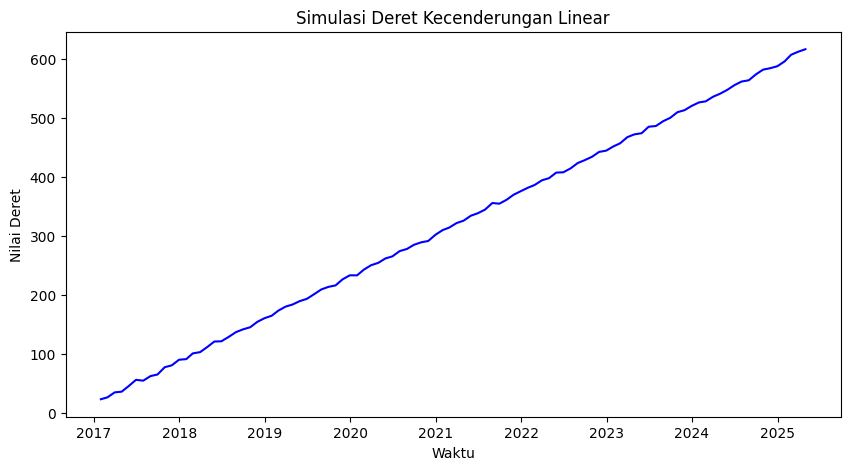

In [80]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

jawaban : Berdasarkan grafik, terdapat indikasi adanya autokorelasi positif atau korelasi serial antar pengamatan. Hal ini terlihat dari pola deret yang meningkat secara konsisten dan adanya tren linear terhadap waktu, sehingga pengamatan yang berdekatan cenderung memiliki nilai yang relatif mirip.

In [81]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 0.9999


In [82]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.102e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.70e-191
Time:                        12:31:45   Log-Likelihood:                -212.90
No. Observations:                 100   AIC:                             429.8
Df Residuals:                      98   BIC:                             435.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           21.6432      0.408     53.064   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Jawaban : Hasil pengepasan model regresi menghasilkan estimasi parameter Beta0= 21,6432 dan Beta1 = 5,9984. Nilai R square =1,000 menunjukkan bahwa model regresi linear mampu menjelaskan hampir seluruh variasi nilai deret berdasarkan waktu. Selain itu, model sangat signifikan dan nilai Durbin-Watson sebesar 2.242 menunjukkan tidak adanya masalah autokorelasi residual yang berarti.

Apakah model regresi yang dipaskan sudah bagus?

Jawaban : Model regresi yang dipaskan dapat dinilai sangat baik atau sudah bagus dalam menggambarkan deret yang memiliki kecenderungan linear terhadap waktu.



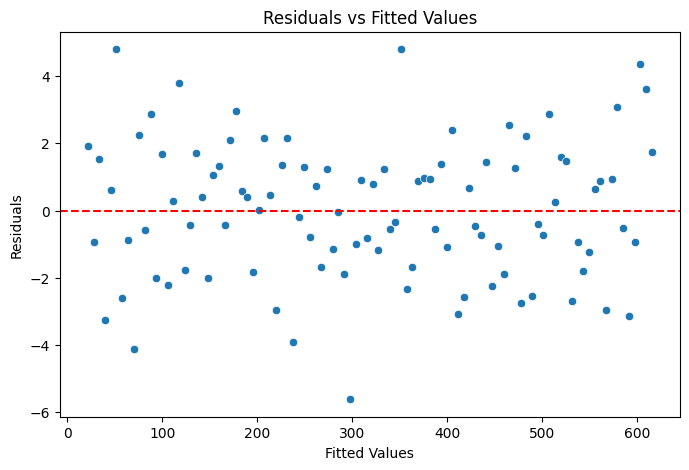

In [83]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

pada plot tersebut residual berada di atas dan di bawah garis nol secara acak (random). Tidak tampak pola melengkung atau pola sistemastis sehingga asumsi linearitas terpenuhi. Penyebaran residual relatif tidak menunjukkan pola yang semakin melebar atau menyempit secara jelas atau tidak menunjukkan heteroskedastisitas dari plot tersebut. Sehingga model regresi dapat dikatakan sudah baik berdasarkan plot residual ini.

In [84]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.8354


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

jawaban : Hasil uji Breusch–Pagan menunjukkan nilai p-value sebesar 0,8354 (> 0,05), sehingga H₀ tidak ditolak. Kesimpulannya tidak terdapat indikasi heteroskedastisitas pada model regresi, sehingga asumsi homoskedastisitas residual terpenuhi.

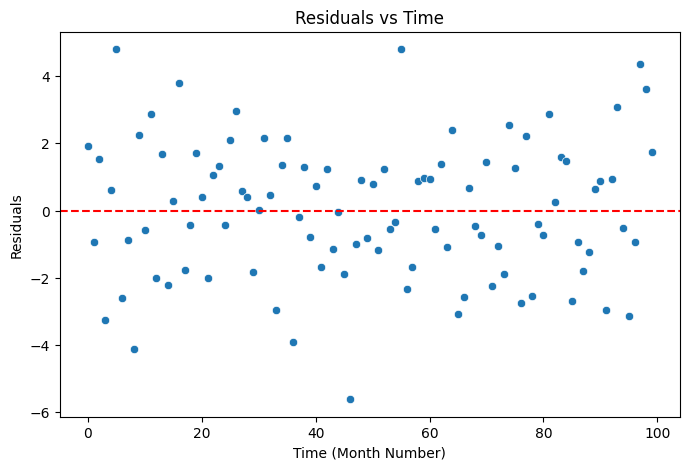

In [85]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

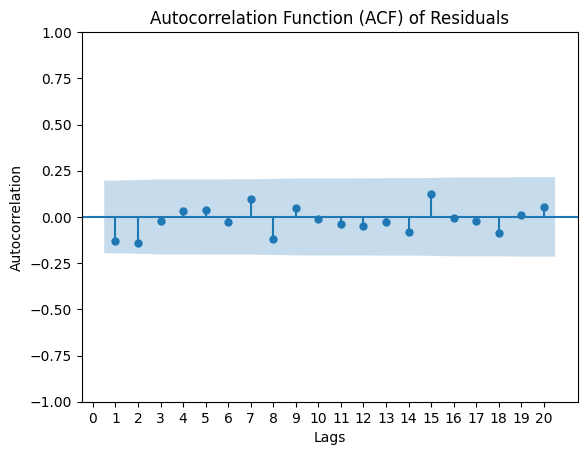

In [86]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Jawaban : Residual model menunjukkan penyebaran yang relatif acak di sekitar nol dan tidak memperlihatkan pola sistematis terhadap waktu. Plot ACF menunjukkan bahwa autokorelasi residual pada lag 1–20 tidak signifikan karena seluruh nilai ACF berada dalam batas confidence interval. Kesimpulannya residual model tidak menunjukkan masalah heteroskedastisitas maupun autokorelasi yang berarti.

In [87]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    1.709979   0.190988
2    3.795404   0.149913
3    3.846979   0.278469
4    3.968497   0.410286
5    4.134886   0.530164
6    4.232168   0.645290
7    5.253597   0.629046
8    6.795386   0.558861
9    7.074868   0.629325
10   7.084563   0.717438
11   7.250488   0.778451
12   7.505292   0.822498
13   7.584802   0.869559
14   8.396061   0.867689
15  10.194511   0.807329
16  10.196115   0.856188
17  10.249775   0.892810
18  11.235756   0.884086
19  11.245810   0.915293


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Jawaban : Hasil uji Ljung–Box menunjukkan bahwa seluruh p-value pada lag 1–19 lebih besar dari 0,05 sehingga H₀ tidak ditolak, tidak terdapat bukti adanya autokorelasi yang signifikan pada residual hingga lag 19. Dengan kata lain, residual model dapat dianggap tidak memiliki autokorelasi yang signifikan dan telah memenuhi karakteristik residual yang mendekati white noise.

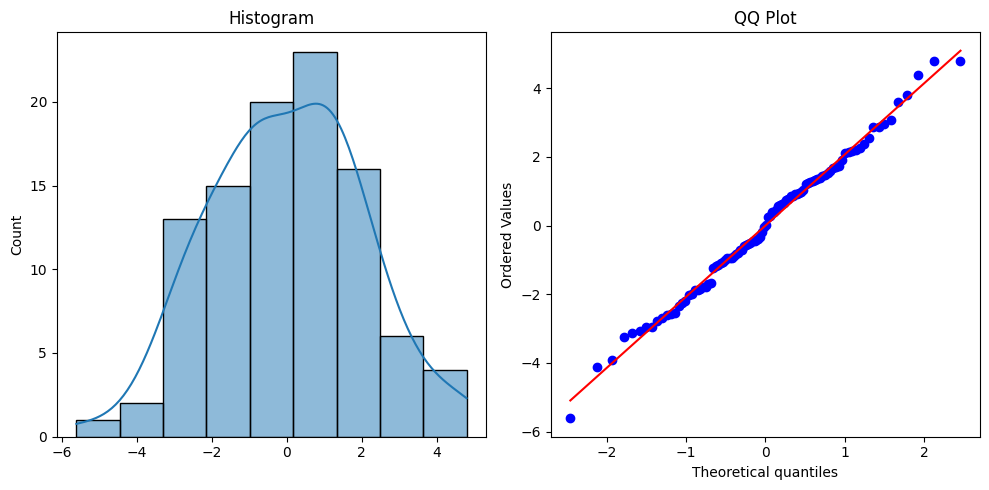

In [88]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Jawaban : Berdasarkan histogram dan Q-Q plot, residual secara umum berdistribusi mendekati normal. Sebagian besar titik pada Q-Q plot mengikuti garis referensi, sedangkan penyimpangan terutama terjadi pada bagian ekor distribusi sehingga asumsi normalitas residual dapat dianggap cukup terpenuhi, meskipun terdapat beberapa observasi ekstrem yang perlu diperhatikan.

In [89]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9932165174089963, p-value = 0.9007730458109933


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Jawaban
Hasil uji Shapiro–Wilk menghasilkan statistik W = 0,9932 dengan p-value = 0,9008 (> 0,05), sehingga H₀ tidak ditolak sehingga tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal dan asumsi normalitas residual dapat dianggap terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [90]:
# Menentukan parameter simulasi
np.random.seed(2025)
n_periods = 120
beta_0, beta_1, beta_2= 50 + 12, 0.5 * 12, 0.02 *12
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

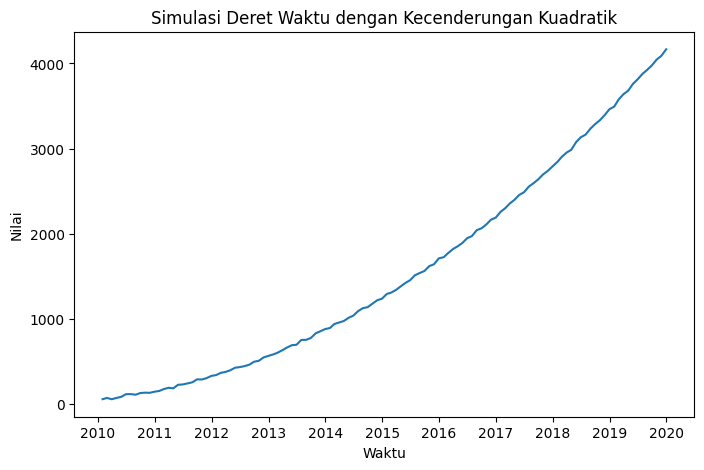

In [91]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Jawaban : Deret menunjukkan kecenderungan meningkat dengan pola nonlinear atau kuadratik. Hal ini terlihat dari kurva yang semakin curam seiring bertambahnya waktu, sehingga laju kenaikan nilai deret semakin besar. Terdapat variasi atau penyimpangan kecil di sekitar tren tersebut. Perbedaannya dengan tren linear adalah pada tren linear nilai deret berubah dengan laju yang relatif konstan sehingga membentuk pola garis lurus, sedangkan pada tren kuadratik laju perubahan nilai tidak konstan dan pada grafik ini semakin meningkat sehingga membentuk kurva yang semakin curam.

In [92]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.597e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.65e-247
Time:                        12:32:54   Log-Likelihood:                -441.14
No. Observations:                 120   AIC:                             888.3
Df Residuals:                     117   BIC:                             896.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.7612      2.607     24.458      0.0

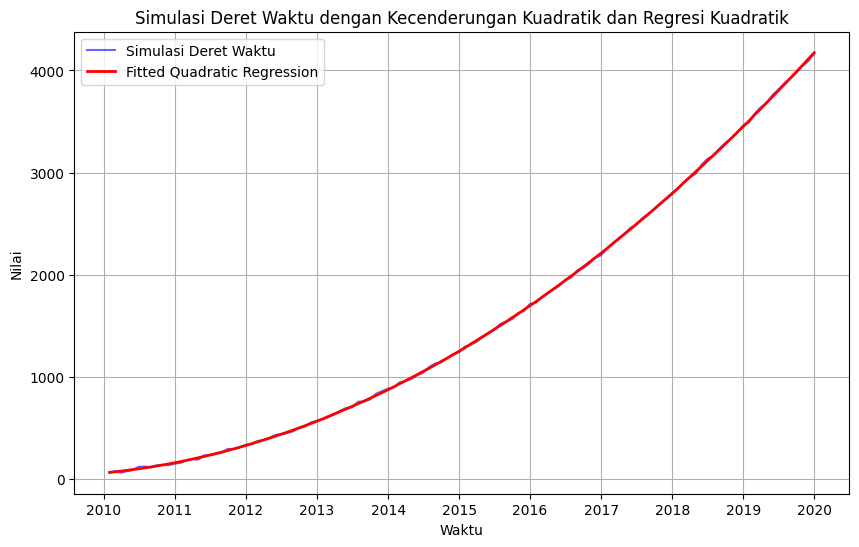

In [93]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Jawaban : Model regresi kuadratik yang dipasangkan terhadap deret mampu mengikuti pola kecenderungan data dengan baik. Model regresi kuadratik memberikan kecocokan yang sangat baik terhadap deret waktu, dengan R square= 1,00 dan uji F yang sangat signifikan (p < 0,001). Komponen kuadratik juga signifikan dan bernilai positif, sehingga model mampu menangkap pola tren nonlinear yang semakin meningkat. Pemeriksaan residual menunjukkan tidak terdapat bukti heteroskedastisitas maupun autokorelasi yang signifikan, sementara asumsi normalitas residual terpenuhi. Dengan demikian, model regresi kuadratik dapat dinilai memadai dan sesuai untuk menggambarkan pola deret yang memiliki kecenderungan kuadratik.

In [94]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [95]:
# Menentukan parameter simulasi
np.random.seed(100)
n_periods = 120
beta0, beta1, beta2=50 + 12,-25 * 12, -2 * 12
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


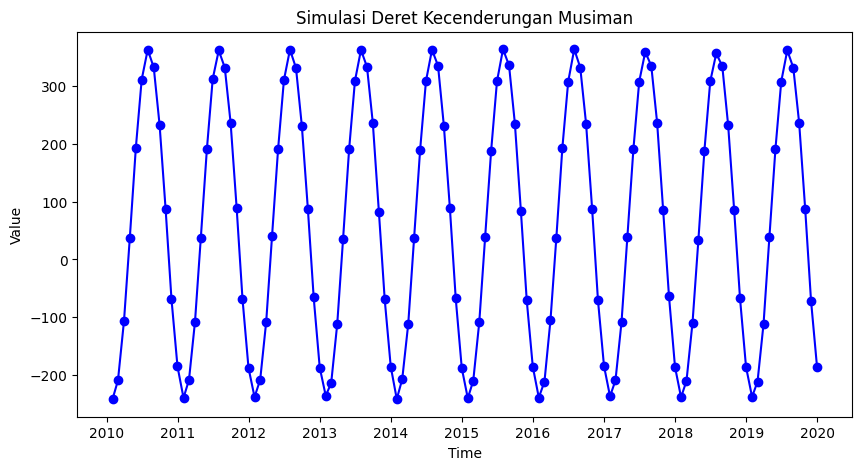

In [96]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Jawaban : Deret menunjukkan pola musiman yang kuat dengan periode musiman 12. Hal ini ditunjukkan oleh pola naik dan turun yang berulang secara konsisten setiap 12 periode. Puncak dan lembah muncul secara periodik dari tahun ke tahun, sementara tidak terlihat adanya kecenderungan tren jangka panjang yang dominan sehingga karakteristik utama deret adalah komponen musiman dengan periode musiman 12.

In [97]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [98]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [99]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [100]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.289e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.08e-217
Time:                        12:33:46   Log-Likelihood:                -244.46
No. Observations:                 120   AIC:                             512.9
Df Residuals:                     108   BIC:                             546.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -238.5532      0.619   -385.683      0.0

Bagaimana interpretasi dari hasil tersebut?

Jawaban : Hasil regresi dengan variabel dummy bulan menunjukkan adanya pola musiman yang kuat selama periode 12 bulan. Koefisien bulan menunjukkan bahwa nilai deret relatif rendah pada Januari–Maret, kemudian meningkat mulai April dan mencapai nilai tertinggi pada Juli sebesar 361,2541, sebelum kembali menurun hingga Desember. Seluruh koefisien bulan signifikan secara statistik (p < 0,001), sehingga komponen musiman memberikan kontribusi yang signifikan terhadap deret.

Model memiliki nilai R square = 1,000, yang menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Uji F juga sangat signifikan (p < 0,001), sehingga variabel bulan secara keseluruhan berpengaruh signifikan terhadap deret. Nilai Durbin-Watson sebesar 1,982 tidak menunjukkan indikasi kuat adanya autokorelasi residual. Selain itu, uji Jarque-Bera menghasilkan p-value 0,543 > 0,05, sehingga tidak terdapat bukti yang cukup bahwa residual menyimpang dari distribusi normal. Dengan demikian, model dummy musiman ini sangat baik dalam menggambarkan pola musiman pada deret tersebut.

In [101]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

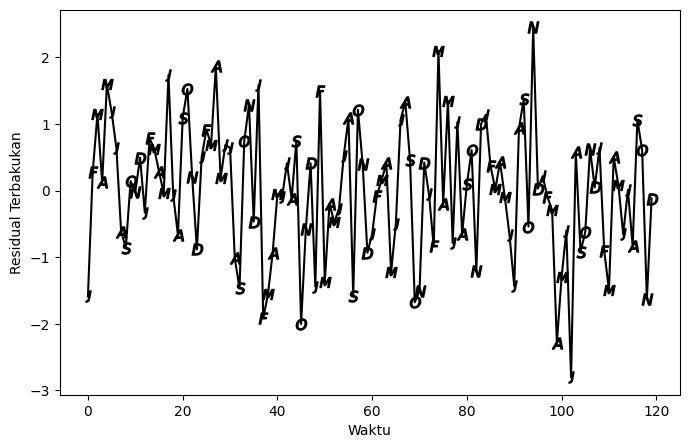

In [102]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


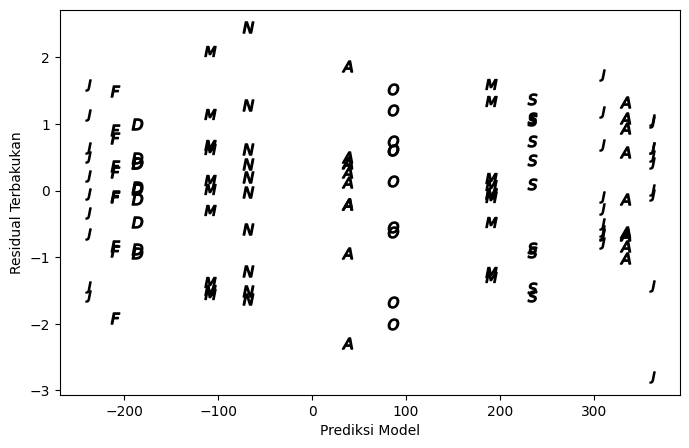

In [103]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

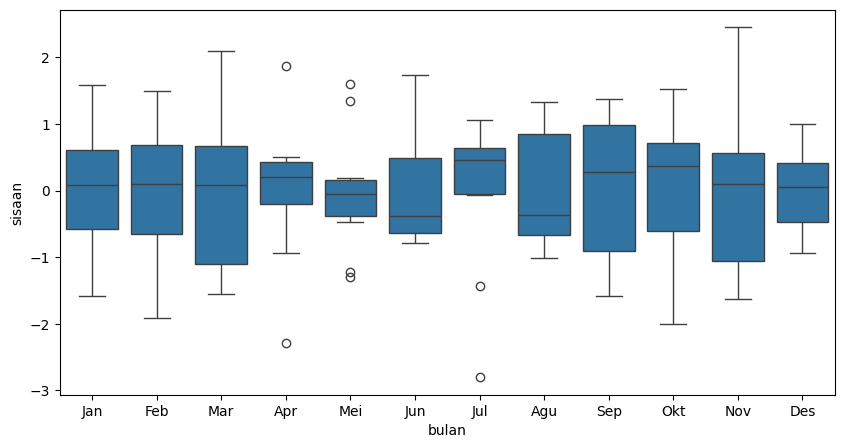

In [104]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

Jawaban : Berdasarkan ketiga plot, residual terstandarisasi secara umum tersebar di sekitar nol dan tidak menunjukkan pola sistematis atau pola musiman yang kuat. Plot residual terhadap waktu menunjukkan bahwa residual tidak memiliki kecenderungan naik atau turun secara konsisten. Plot residual terhadap nilai prediksi juga tidak menunjukkan pola melengkung maupun pola corong yang jelas. Sementara itu, boxplot berdasarkan bulan menunjukkan bahwa median residual pada sebagian besar bulan berada di sekitar nol, meskipun terdapat beberapa nilai residual ekstrem dan variasi penyebaran antarbulan. Secara keseluruhan, ketiga plot menunjukkan bahwa model telah menangkap pola musiman utama dengan cukup baik dan tidak terdapat indikasi visual yang kuat adanya masalah pada residual.

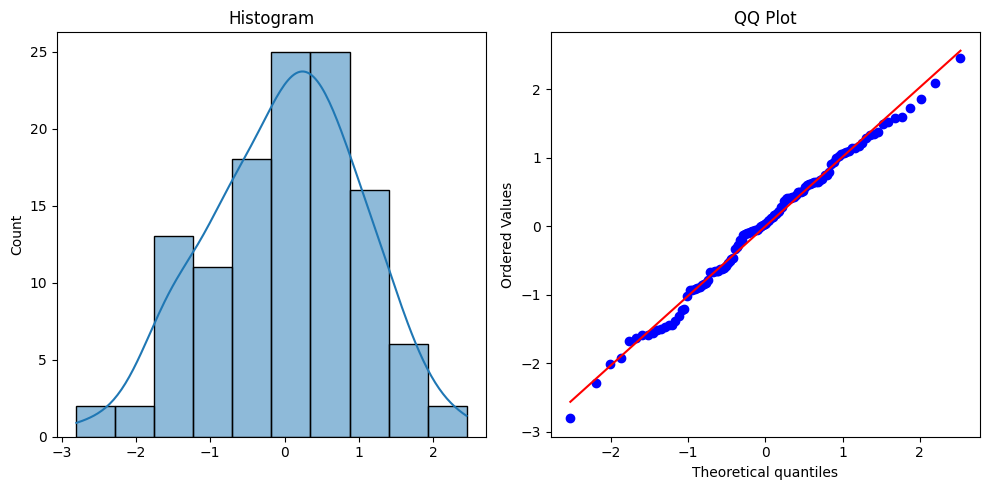

In [105]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

Jawaban : Berdasarkan histogram dan Q-Q plot, residual secara visual mendekati distribusi normal. Hasil uji Jarque-Bera juga menunjukkan p-value 0,543 > 0,05, sehingga tidak terdapat bukti yang cukup untuk menolak asumsi normalitas residual. Hasil Durbin-Watson sebesar 1,982 dan uji Ljung-Box menunjukkan tidak adanya indikasi autokorelasi residual yang signifikan. Berdasarkan pemeriksaan tersebut, model dapat dinilai cukup baik dalam memenuhi asumsi normalitas dan independensi residual. Untuk memastikan asumsi homoskedastisitas, diperlukan uji Breusch-Pagan.

In [106]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [107]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [108]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.289e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.08e-217
Time:                        12:34:27   Log-Likelihood:                -244.46
No. Observations:                 120   AIC:                             512.9
Df Residuals:                     108   BIC:                             546.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -238.5532      0.619   -385.683      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Jawaban : Pada model tanpa intersep, masing-masing koefisien bulan secara langsung merepresentasikan level atau nilai rata-rata deret untuk bulan tersebut. Sedangkan pada model dengan intersep, Januari digunakan sebagai kategori referensi. Intersep sebesar −238,5532 merepresentasikan nilai model untuk bulan Januari, sedangkan koefisien masing-masing bulan menunjukkan perbedaan nilai bulan tersebut terhadap Januari. Sebagai contoh, koefisien Februari sebesar 28,9228 berarti nilai Februari diperkirakan 28,9228 lebih tinggi daripada Januari. Nilai prediksi Februari adalah −238,5532 + 28,9228 = −209,6304. Dengan cara yang sama, koefisien Juli sebesar 599,8073 menunjukkan bahwa nilai Juli 599,8073 lebih tinggi daripada Januari, sehingga nilai prediksi Juli adalah 361,2541. Hasil ini menunjukkan bahwa model dengan intersep dan model tanpa intersep memberikan nilai fitted yang sama, tetapi menggunakan cara parameterisasi dan interpretasi koefisien yang berbeda.

Apakah model dengan intersep sudah memenuhi asumsi regresi?

Jawaban : Berdasarkan hasil diagnostik, model dengan intersep secara umum telah memenuhi asumsi regresi yang diperiksa. Residual secara visual mendekati distribusi normal dan uji Jarque-Bera menghasilkan p-value 0,543 > 0,05. Nilai Durbin-Watson sebesar 1,982 dan hasil uji Ljung-Box juga tidak menunjukkan adanya autokorelasi residual yang signifikan. Plot residual tidak menunjukkan pola sistematis atau pola pelebaran/penyempitan yang jelas. Dengan demikian, model dapat dinilai cukup baik berdasarkan pemeriksaan asumsi tersebut. Namun, untuk memastikan asumsi homoskedastisitas secara formal, tetap diperlukan uji seperti Breusch-Pagan.

In [109]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [110]:
# Parameter
np.random.seed(1012)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5 * 12, 10 * 12#(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


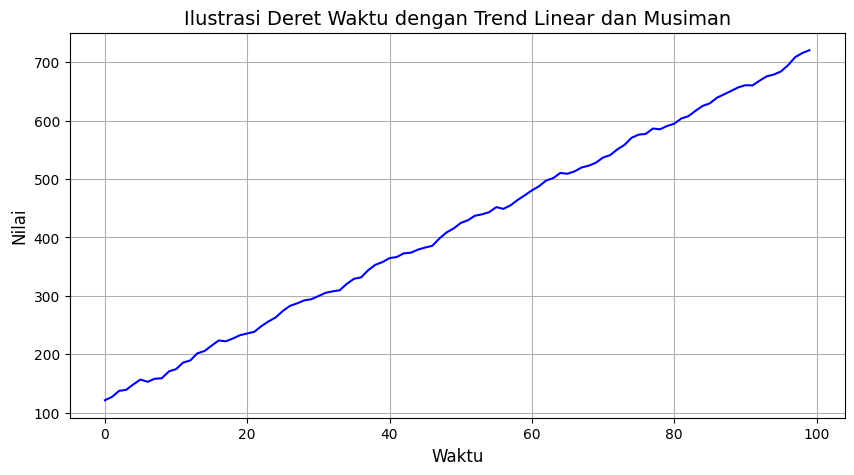

In [111]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

Gambar tersebut menunjukkan deret waktu yang memiliki dua komponen sekaligus, yaitu tren linear dan pola musiman. Jadi, model yang sesuai memang sebaiknya memasukkan variabel waktu (tren) dan variabel musiman secara bersamaan.

In [112]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [113]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [114]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.701e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.24e-164
Time:                        12:35:20   Log-Likelihood:                -208.77
No. Observations:                 100   AIC:                             443.5
Df Residuals:                      87   BIC:                             477.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      119.2935      0.780    152.968      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?
Koefisien regresi pada model ini terdiri atas koefisien untuk masing-masing bulan dan koefisien tren waktu (period). Karena model tidak menggunakan intersep, koefisien setiap bulan menunjukkan level dasar deret untuk bulan tersebut. Sebagai contoh, koefisien Januari sebesar 119,2935 menunjukkan level dasar pada bulan Januari, sedangkan koefisien Februari sebesar 122,2161 menunjukkan level dasar pada bulan Februari. Nilai prediksi aktual diperoleh dengan menambahkan level bulan tersebut dengan kontribusi tren waktu.

Koefisien period sebesar 5,9984 menunjukkan bahwa setiap kenaikan satu periode waktu meningkatkan nilai deret rata-rata sebesar 5,9984 satuan setelah memperhitungkan efek musiman. Dengan demikian, model menunjukkan adanya tren linear positif sekaligus komponen musiman.

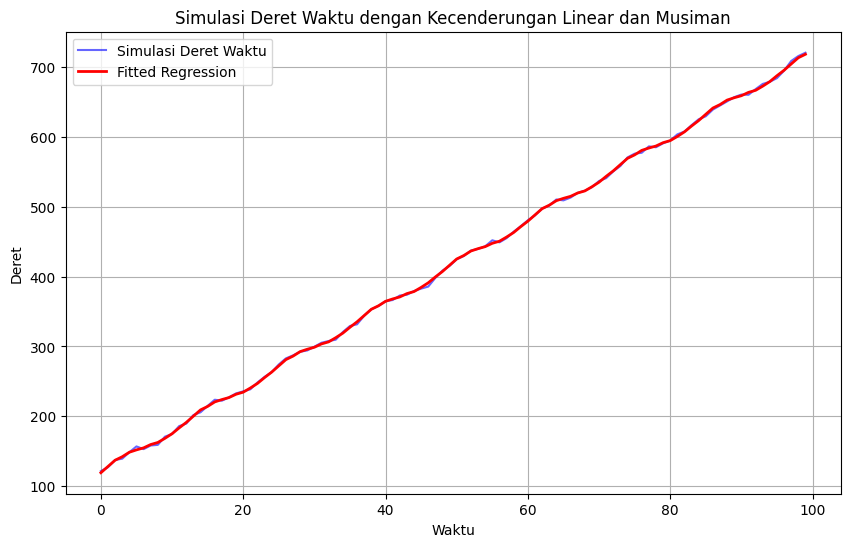

In [115]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

Berdasarkan grafik hasil pengepasan model, garis fitted regression hampir berhimpit dengan deret aktual. Hal ini menunjukkan bahwa model mampu menangkap pola tren linear dan pola musiman dengan sangat baik. Hasil diagnostik juga menunjukkan bahwa residual berdistribusi mendekati normal, ditunjukkan oleh uji Jarque-Bera dengan p-value 0,868 > 0,05. Nilai Durbin-Watson sebesar 2,174 juga tidak menunjukkan indikasi autokorelasi yang kuat. Plot residual tidak menunjukkan pola sistematis yang jelas. Dengan demikian, berdasarkan pemeriksaan yang telah dilakukan, tidak terdapat indikasi kuat pelanggaran asumsi normalitas dan independensi residual. Namun, asumsi homoskedastisitas perlu dikonfirmasi dengan uji Breusch-Pagan. Secara keseluruhan, model dapat dinilai cukup baik dalam memenuhi asumsi regresi.

In [116]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [117]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

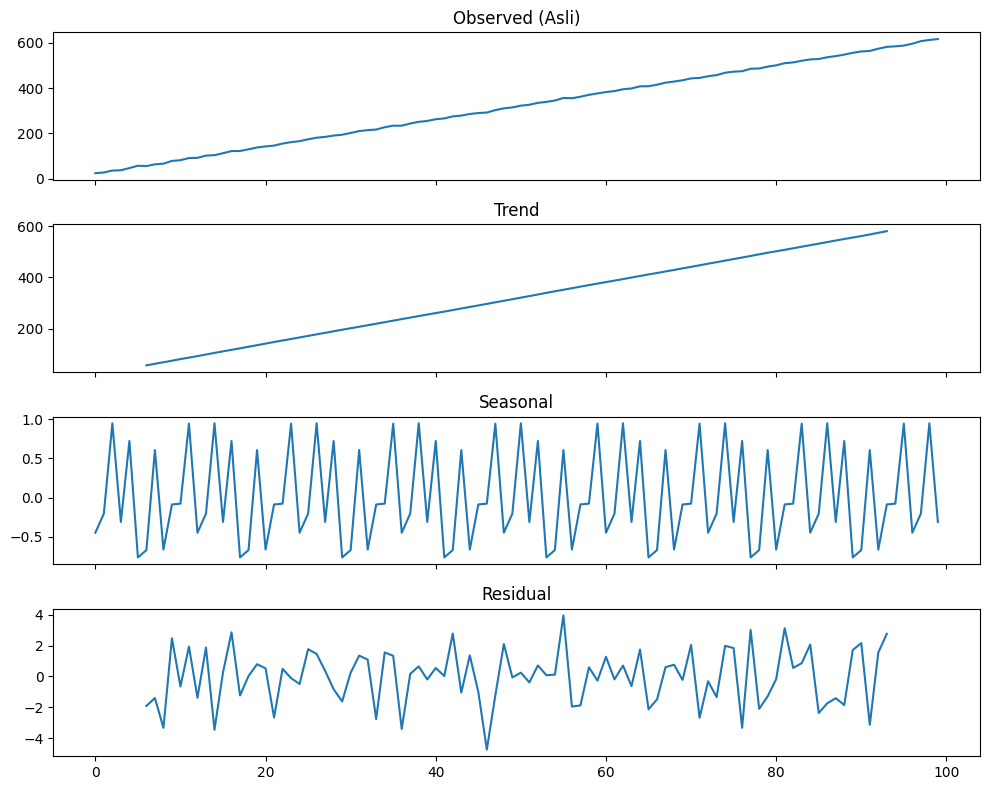

In [118]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi, deret waktu terdiri atas komponen observed, trend, seasonal, dan residual. Komponen observed menunjukkan adanya kecenderungan peningkatan nilai deret dari waktu ke waktu. Komponen trend memperlihatkan pola meningkat yang hampir linear, sehingga menunjukkan adanya tren positif dalam jangka panjang. Komponen seasonal menunjukkan pola naik-turun yang berulang secara teratur, sehingga terdapat pola musiman dalam deret. Sementara itu, residual berfluktuasi di sekitar nol tanpa menunjukkan pola tren yang jelas, yang menunjukkan bahwa sebagian besar struktur sistematis dalam data telah ditangkap oleh komponen tren dan musiman. Dengan demikian, deret tersebut memiliki karakteristik utama berupa tren linear positif dan pola musiman, sedangkan residual merupakan variasi yang tidak dijelaskan oleh kedua komponen tersebut.


In [119]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

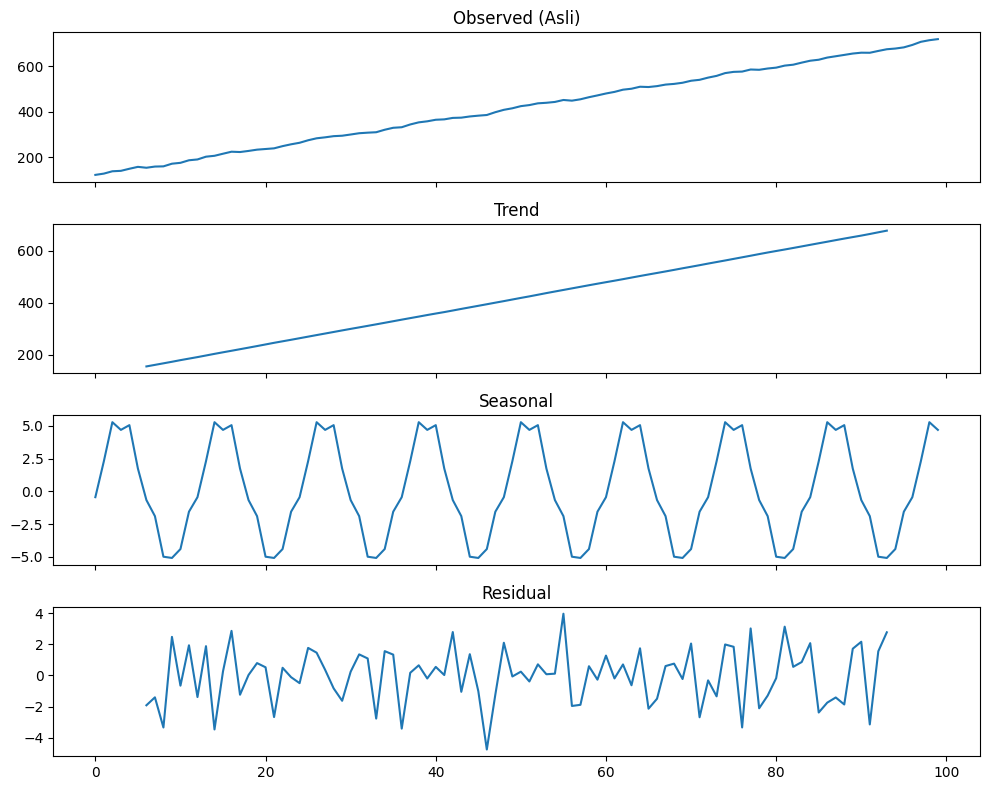

In [120]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi, deret waktu terdiri atas komponen observed, trend, seasonal, dan residual. Komponen observed menunjukkan adanya kecenderungan peningkatan nilai dari waktu ke waktu yang disertai fluktuasi berulang. Komponen trend menunjukkan pola meningkat yang hampir linear, sehingga terdapat tren linear positif dalam deret. Komponen seasonal menunjukkan pola naik-turun yang berulang secara teratur dengan periode sekitar 12, dengan amplitudo sekitar −5 hingga +5, sehingga menunjukkan adanya pola musiman yang relatif konstan. Sementara itu, komponen residual berfluktuasi di sekitar nol tanpa menunjukkan pola tren atau musiman yang jelas. Dengan demikian, karakteristik utama deret adalah adanya tren linear positif dan pola musiman periode 12, sedangkan residual merupakan variasi yang tidak dijelaskan oleh kedua komponen tersebut.

Hubungannya dengan model regresi Anda

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [121]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1012)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 * 12, 10 * 12 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

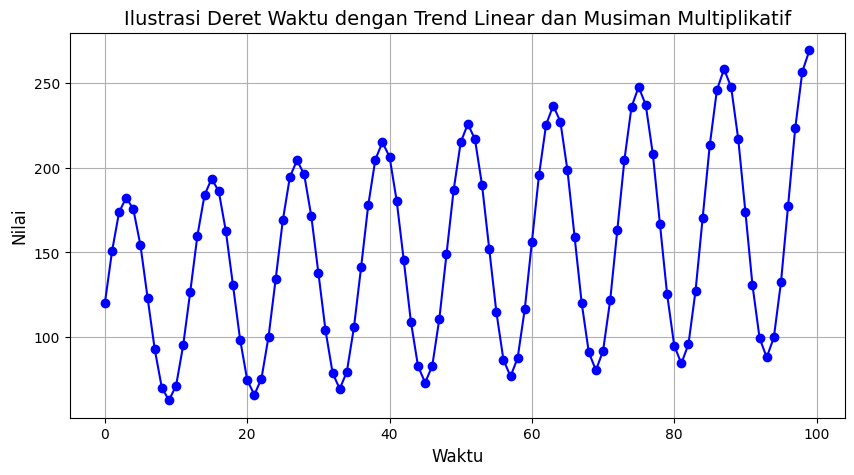

In [122]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

Jawaban : Berdasarkan grafik, deret waktu menunjukkan adanya tren linear positif yang disertai pola musiman yang kuat dan berulang secara teratur dengan periode sekitar 12. Berbeda dengan pola musiman aditif, amplitudo fluktuasi musiman pada deret ini cenderung meningkat seiring meningkatnya level deret. Ketika nilai deret semakin tinggi, jarak antara puncak dan lembah musiman juga semakin besar. Karakteristik tersebut menunjukkan bahwa deret lebih sesuai dengan pola dekomposisi multiplikatif, yaitu Yt=Tt x St x Et. Karena seluruh nilai deret pada grafik bernilai positif, dekomposisi multiplikatif dapat diterapkan tanpa perlu melakukan transformasi terlebih dahulu.

In [123]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

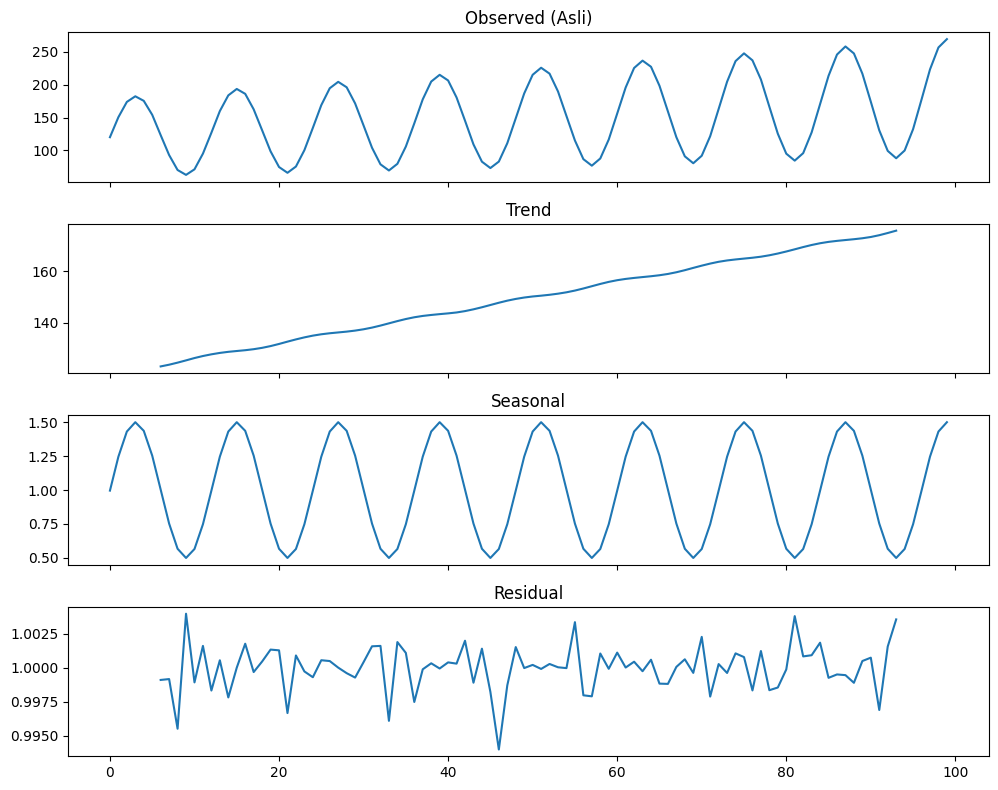

In [124]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

Jawaban : Berdasarkan hasil dekomposisi multiplikatif, deret waktu menunjukkan adanya tren jangka panjang yang meningkat dan pola musiman yang kuat dengan periode sekitar 12. Komponen trend meningkat secara bertahap dari waktu ke waktu, sedangkan komponen seasonal menunjukkan pola yang berulang secara teratur dengan nilai sekitar 0,5–1,5. Karena menggunakan dekomposisi multiplikatif, nilai seasonal ditafsirkan sebagai faktor pengali terhadap trend, dengan nilai di atas 1 menunjukkan peningkatan dan nilai di bawah 1 menunjukkan penurunan relatif terhadap trend. Komponen residual berfluktuasi sangat dekat dengan nilai 1 dan tidak menunjukkan pola sistematis yang jelas. Hal ini menunjukkan bahwa kombinasi trend dan pola musiman telah menjelaskan sebagian besar variasi sistematis dalam deret. Dengan demikian, deret tersebut memiliki karakteristik utama berupa tren meningkat dan pola musiman multiplikatif yang kuat.

In [125]:
# Parameter
np.random.seed(1012)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

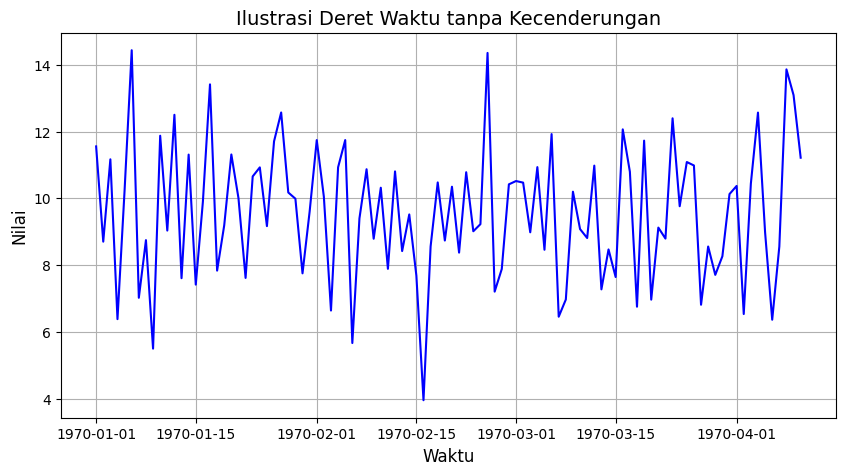

In [126]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

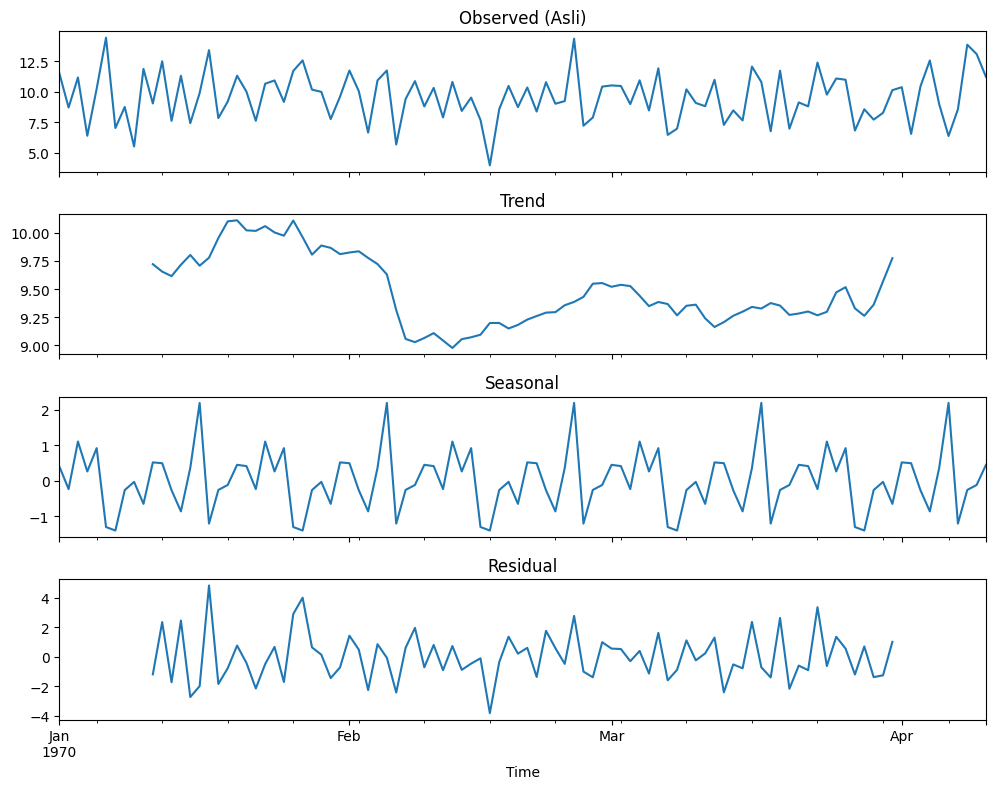

In [127]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?
Jawaban :

Berdasarkan hasil dekomposisi, deret waktu menunjukkan adanya komponen trend yang berfluktuasi tanpa kecenderungan naik atau turun yang konsisten sepanjang periode pengamatan. Komponen seasonal menunjukkan pola naik-turun yang berulang secara teratur dan berfluktuasi di sekitar nilai nol, sehingga menunjukkan adanya pola musiman yang bersifat aditif. Sementara itu, residual berfluktuasi di sekitar nol dan masih menunjukkan variasi yang cukup besar tanpa pola sistematis yang jelas. Dengan demikian, deret dapat dipandang sebagai gabungan antara perubahan trend, pola musiman yang berulang, dan variasi acak yang tidak dijelaskan oleh kedua komponen tersebut.